In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

#NA: PSI = if the expression is 0 for all the transcripts involved in the event or if the event does not pass any 
# he transcript expression filter (see PSI calculation, Command and options). Also if one or more transcripts of 
# the event do not appear in the expression file, an NA will be returned

'/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/GSE73721/SRR2557112/SUPPA'

In [77]:
def summarize_suppa_events(suppa_file, plot="no"):
    
    # read in the file
    suppa = pd.read_csv(suppa_file, sep="\t")
    # split index column by ";" and first part goes into one column and second part goes into another column
    suppa["gene_id"] = suppa.index.str.split(";").str[0]
    suppa["splicing"] = suppa.index.str.split(";").str[1]
    suppa["splicing_event"] = suppa.splicing.str.split(":").str[0]
    suppa["chr"] = suppa.splicing.str.split(":").str[1]
    suppa["e1s2"] = suppa.splicing.str.split(":").str[2]
    suppa["e2s3"] = suppa.splicing.str.split(":").str[3]
    suppa["strand"] = suppa.splicing.str.split(":").str[4]
    
    # rename first column to be "PSI"
    suppa = suppa.rename(columns={suppa.columns[0]: "PSI"})
    # keep only events that not NA in astrocytes_bulk PSI 
    suppa = suppa.dropna(subset=['PSI'])                       

    # plot distribution of PSI values across all events 
    if plot == "yes":
        suppa.PSI.hist()
        plt.ylabel('Frequency', fontsize=14)
        plt.xlabel('PSI per local event', fontsize=14)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.title(suppa.splicing_event.unique(), fontsize=16)

    # what is the average number of events per gene 
    print("The average number of events per gene is: ", suppa.groupby("gene_id").size().mean())
    print("The number of unique events is: ", suppa.splicing.nunique(), "for event type", suppa.splicing_event.unique())

    return(suppa)

In [84]:
se_bulk[se_bulk["gene_id"] == "ENSMUSG00000025006"]

,PSI,gene_id,splicing,splicing_event,chr,e1s2,e2s3,strand
ENSMUSG00000025006;SE:19:40299521-40300243:40300302-40311669:-,0.185159,ENSMUSG00000025006,SE:19:40299521-40300243:40300302-40311669:-,SE,19,40299521-40300243,40300302-40311669,-
ENSMUSG00000025006;SE:19:40299521-40309581:40310333-40311669:-,0.000000,ENSMUSG00000025006,SE:19:40299521-40309581:40310333-40311669:-,SE,19,40299521-40309581,40310333-40311669,-
ENSMUSG00000025006;SE:19:40318068-40321793:40321960-40324747:-,0.221421,ENSMUSG00000025006,SE:19:40318068-40321793:40321960-40324747:-,SE,19,40318068-40321793,40321960-40324747,-
ENSMUSG00000025006;SE:19:40324832-40325471:40326937-40327450:-,0.090818,ENSMUSG00000025006,SE:19:40324832-40325471:40326937-40327450:-,SE,19,40324832-40325471,40326937-40327450,-
ENSMUSG00000025006;SE:19:40337035-40340045:40340146-40340685:-,0.450582,ENSMUSG00000025006,SE:19:40337035-40340045:40340146-40340685:-,SE,19,40337035-40340045,40340146-40340685,-
ENSMUSG00000025006;SE:19:40340146-40340685:40340750-40344356:-,0.457991,ENSMUSG00000025006,SE:19:40340146-40340685:40340750-40344356:-,SE,19,40340146-40340685,40340750-40344356,-
ENSMUSG00000025006;SE:19:40352565-40361042:40361104-40361429:-,0.090659,ENSMUSG00000025006,SE:19:40352565-40361042:40361104-40361429:-,SE,19,40352565-40361042,40361104-40361429,-
ENSMUSG00000025006;SE:19:40352565-40361429:40361503-40363202:-,0.424837,ENSMUSG00000025006,SE:19:40352565-40361429:40361503-40363202:-,SE,19,40352565-40361429,40361503-40363202,-
ENSMUSG00000025006;SE:19:40365166-40369690:40369719-40373476:-,0.723676,ENSMUSG00000025006,SE:19:40365166-40369690:40369719-40373476:-,SE,19,40365166-40369690,40369719-40373476,-
ENSMUSG00000025006;SE:19:40373617-40376645:40376803-40376984:-,0.059315,ENSMUSG00000025006,SE:19:40373617-40376645:40376803-40376984:-,SE,19,40373617-40376645,40376803-40376984,-


In [83]:
se_bulk.groupby("gene_id").size().sort_values(ascending=False).head(10)

gene_id
ENSMUSG00000025006    18
ENSMUSG00000040537    16
ENSMUSG00000024921    15
ENSMUSG00000063142    15
ENSMUSG00000064302    14
ENSMUSG00000032826    14
ENSMUSG00000022607    14
ENSMUSG00000069601    14
ENSMUSG00000022708    13
ENSMUSG00000045962    13
dtype: int64

In [102]:
se_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/GSE73721/SRR2557112/SUPPA/PSI/suppa_MM10_local_SE_strict.psi')
mx_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/GSE73721/SRR2557112/SUPPA/PSI/suppa_MM10_local_MX_strict.psi')
ri_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/GSE73721/SRR2557112/SUPPA/PSI/suppa_MM10_local_RI_strict.psi')
af_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/GSE73721/SRR2557112/SUPPA/PSI/suppa_MM10_local_AF_strict.psi')
al_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/GSE73721/SRR2557112/SUPPA/PSI/suppa_MM10_local_AL_strict.psi')
a5_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/GSE73721/SRR2557112/SUPPA/PSI/suppa_MM10_local_A5_strict.psi')

The average number of events per gene is:  1.9845581138839101
The number of unique events is:  14390 for event type ['SE']
The average number of events per gene is:  1.3069828722002634
The number of unique events is:  992 for event type ['MX']
The average number of events per gene is:  1.452938577110031
The number of unique events is:  3287 for event type ['RI']
The average number of events per gene is:  3.814697120158888
The number of unique events is:  19207 for event type ['AF']
The average number of events per gene is:  2.1322855271774723
The number of unique events is:  3256 for event type ['AL']
The average number of events per gene is:  1.4836680377449794
The number of unique events is:  6129 for event type ['A5']


In [103]:
len(se_bulk.gene_id.unique())

7253

The average number of events per gene is:  1.8584758942457231
The number of unique events is:  2389 for event type ['SE']
The average number of events per gene is:  1.2352941176470589
The number of unique events is:  147 for event type ['MX']
The average number of events per gene is:  1.3785714285714286
The number of unique events is:  579 for event type ['RI']
The average number of events per gene is:  2.8683385579937304
The number of unique events is:  2745 for event type ['AF']
The average number of events per gene is:  1.795
The number of unique events is:  359 for event type ['AL']
The average number of events per gene is:  1.4285714285714286
The number of unique events is:  990 for event type ['A5']


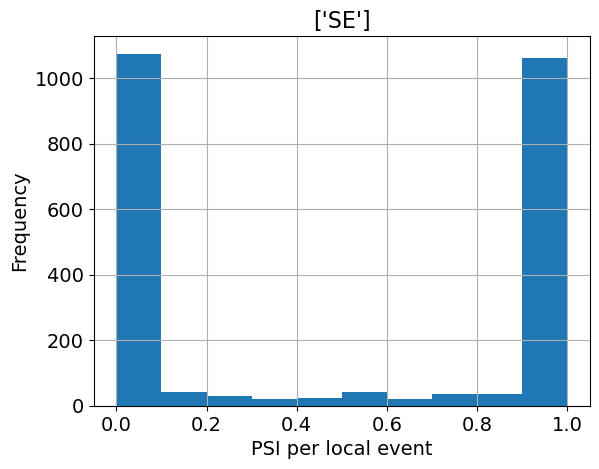

In [97]:
se_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/TM_astrocyte_pseudobulk/SUPPA/single_cell/PSI/suppa_MM10_local_SE_strict.psi', plot="yes")
mx_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/TM_astrocyte_pseudobulk/SUPPA/single_cell/PSI/suppa_MM10_local_MX_strict.psi')
ri_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/TM_astrocyte_pseudobulk/SUPPA/single_cell/PSI/suppa_MM10_local_RI_strict.psi')
af_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/TM_astrocyte_pseudobulk/SUPPA/single_cell/PSI/suppa_MM10_local_AF_strict.psi')
al_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/TM_astrocyte_pseudobulk/SUPPA/single_cell/PSI/suppa_MM10_local_AL_strict.psi')
a5_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/TM_astrocyte_pseudobulk/SUPPA/single_cell/PSI/suppa_MM10_local_A5_strict.psi')

In [99]:
len(se_bulk.gene_id.unique())

1286

In [100]:
se_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/TM_astrocyte_pseudobulk/SUPPA/PSI/suppa_MM10_local_SE_strict.psi')
mx_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/TM_astrocyte_pseudobulk/SUPPA/PSI/suppa_MM10_local_MX_strict.psi')
ri_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/TM_astrocyte_pseudobulk/SUPPA/PSI/suppa_MM10_local_RI_strict.psi')
af_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/TM_astrocyte_pseudobulk/SUPPA/PSI/suppa_MM10_local_AF_strict.psi')
al_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/TM_astrocyte_pseudobulk/SUPPA/PSI/suppa_MM10_local_AL_strict.psi')
a5_bulk = summarize_suppa_events('/gpfs/commons/groups/knowles_lab/Karin/data/BulkRNAseq_Brain/TM_astrocyte_pseudobulk/SUPPA/PSI/suppa_MM10_local_A5_strict.psi')

The average number of events per gene is:  2.012008175779254
The number of unique events is:  15747 for event type ['SE']
The average number of events per gene is:  1.3355780022446688
The number of unique events is:  1190 for event type ['MX']
The average number of events per gene is:  1.4867401060791514
The number of unique events is:  3643 for event type ['RI']
The average number of events per gene is:  4.2634321653189575
The number of unique events is:  23726 for event type ['AF']
The average number of events per gene is:  2.2217962760131433
The number of unique events is:  4057 for event type ['AL']
The average number of events per gene is:  1.538056591357754
The number of unique events is:  7006 for event type ['A5']


In [101]:
len(se_bulk.gene_id.unique())

7828

In [88]:
data = {
    'Event Type': ['SE', 'MX', 'RI', 'AF', 'AL', 'A5'],
    'Bulk': [14390, 992, 3287, 19207, 3256, 6129],
    'Pseudobulk': [15747, 1190, 3643, 23726, 4057, 7006],
    'Single Cell': [2389, 147, 579, 2745, 359, 990]
}

df = pd.DataFrame(data)
# Set 'Event Type' as the index for better labeling
df.set_index('Event Type', inplace=True)
df

,Bulk,Pseudobulk,Single Cell
Event Type,,,
SE,14390,15747,2389
MX,992,1190,147
RI,3287,3643,579
AF,19207,23726,2745
AL,3256,4057,359
A5,6129,7006,990


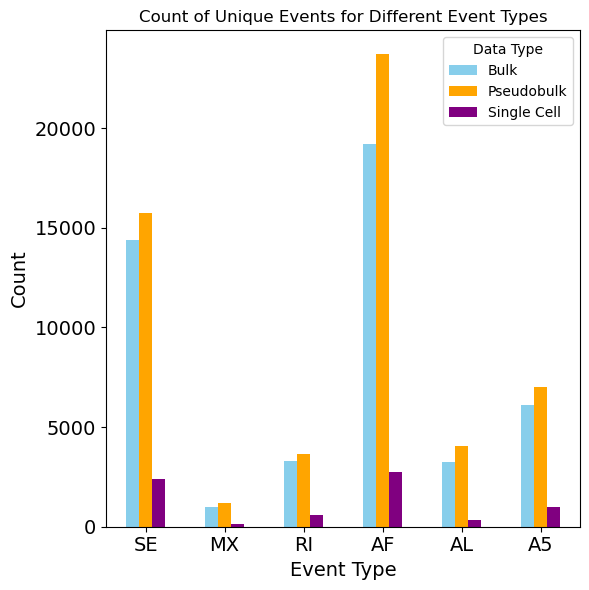

In [89]:
# Plotting
ax = df.plot(kind='bar', figsize=(6, 6), color=['skyblue', 'orange', 'purple'])
plt.title('Count of Unique Events for Different Event Types')
plt.xlabel('Event Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=0, fontsize=14)  # Keep the x-axis labels horizontal
plt.yticks(fontsize=14)  # Keep the x-axis labels horizontal
plt.legend(title='Data Type', bbox_to_anchor=(1, 1))  # Add legend outside the plot
plt.tight_layout()
plt.show()